In [53]:
import numpy as np
import pandas as pd

In [54]:
df = pd.read_csv('spam.csv', encoding='latin-1')

In [55]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
3663,ham,Huh? 6 also cannot? Then only how many mistakes?,NaN,NaN,NaN
3304,ham,Ee msg na poortiyagi odalebeku: Hanumanji 7 na...,NaN,NaN,NaN
4649,ham,Finally it has happened..! Aftr decades..! BEE...,NaN,NaN,NaN
5170,ham,I'm in school now n i'll be in da lab doing so...,NaN,NaN,NaN
468,ham,"Yup, no need. I'll jus wait 4 e rain 2 stop.",NaN,NaN,NaN


In [56]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   v1          5572 non-null   str  
 1   v2          5572 non-null   str  
 2   Unnamed: 2  50 non-null     str  
 3   Unnamed: 3  12 non-null     str  
 4   Unnamed: 4  6 non-null      str  
dtypes: str(5)
memory usage: 217.8 KB


In [57]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [58]:
df.sample(5)

,v1,v2
5434,ham,Jesus armand really is trying to tell everybod...
2020,ham,Anything lor but toa payoh got place 2 walk me...
2332,ham,We are both fine. Thanks
2257,ham,Here got lots of hair dresser fr china.
3386,ham,So u workin overtime nigpun?


In [59]:
df.rename(columns={'v1':'target','v2':'text'},inplace = True)

In [60]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [61]:
df['target'] = encoder.fit_transform(df['target'])

In [62]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [63]:
df.isnull().sum()

target    0
text      0
dtype: int64

In [64]:
df.duplicated().sum()

np.int64(403)

In [65]:
df = df.drop_duplicates(keep='first')

In [66]:

df.duplicated().sum()

np.int64(0)

In [67]:
df.shape

(5169, 2)

# EDA

In [68]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [69]:
df['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

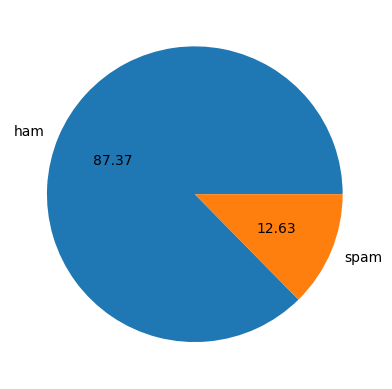

In [70]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['ham','spam'],autopct="%0.2f")
plt.show()

In [71]:
import nltk
from nltk.tokenize import word_tokenize
nltk.data.path.append(r"C:\Users\ht422\nltk_data")

In [72]:
df['num_characters'] = df['text'].apply(len)

In [73]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [74]:
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [75]:
 df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [76]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [77]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [78]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [79]:
#ham
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [80]:
#spam
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [81]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

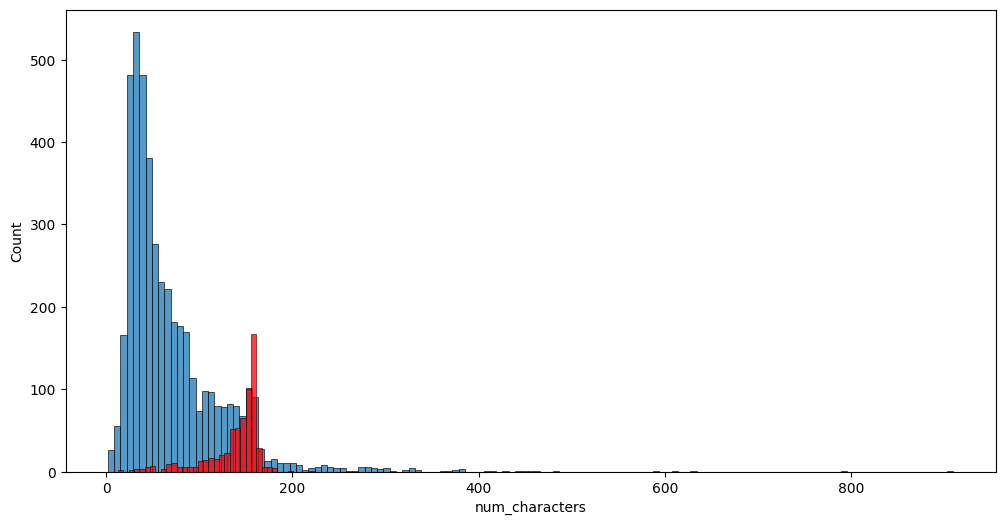

In [82]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'],color = 'red')

<Axes: xlabel='num_words', ylabel='Count'>

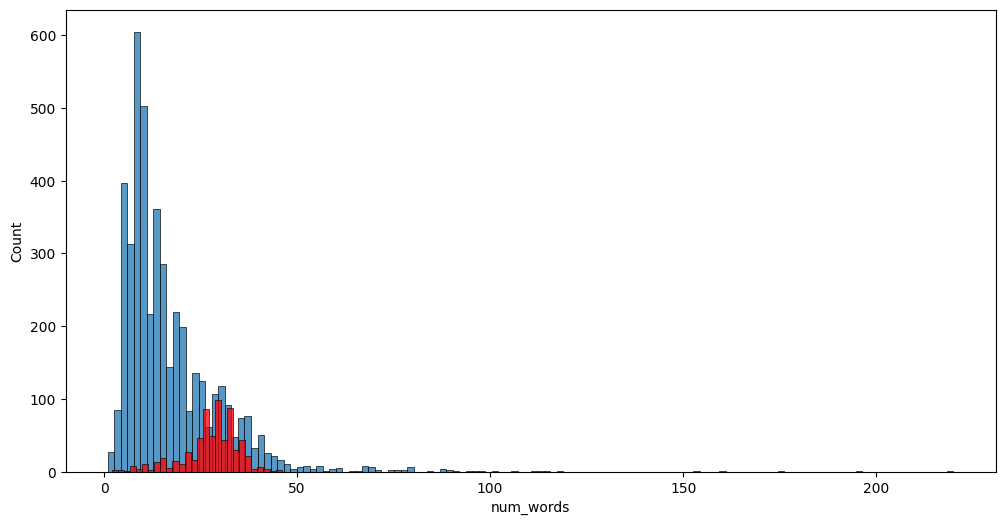

In [83]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'],color = 'red')

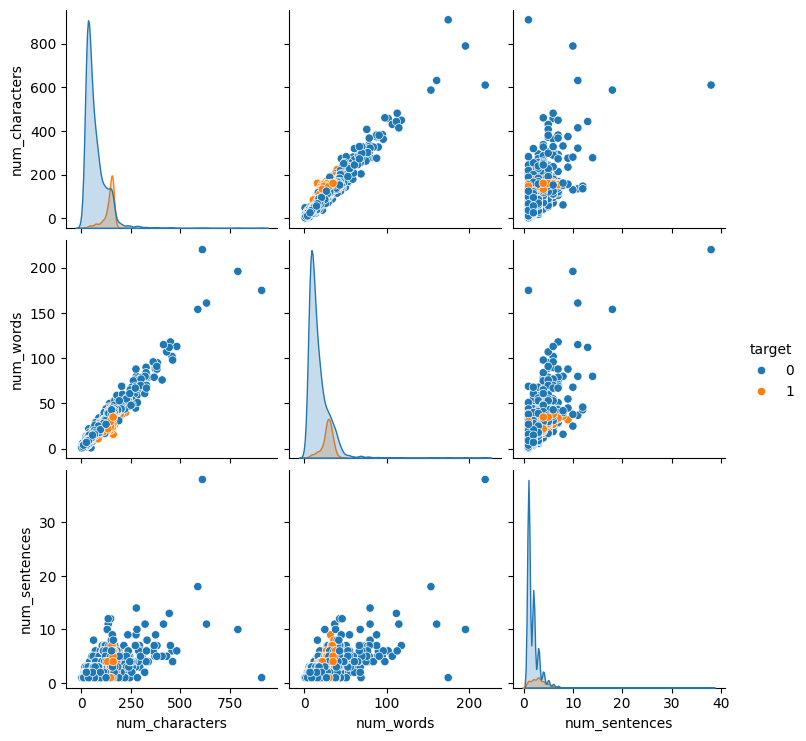

In [84]:
sns.pairplot(df,hue='target')

<Axes: >

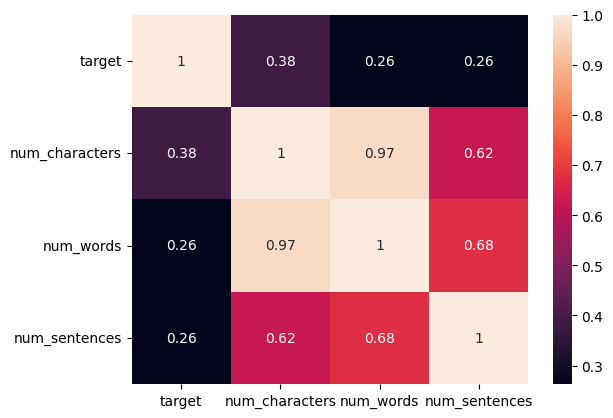

In [85]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)

# Data Preprocessing
 #Lower case, 
 #Tokenization, 
 #Removing special characters, 
 #Removing Stop words and punctuation, 
 #stemming

In [86]:
from nltk.corpus import stopwords
import string
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer

In [87]:
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def transform_text(text):
    # Lowercase
    text = text.lower()
    
    # Tokenize
    words = nltk.word_tokenize(text)
    
    # Remove non-alphanumeric
    words = [word for word in words if word.isalnum()]
    
    # Remove stopwords & punctuation
    words = [word for word in words if word not in stop_words]
    
    # Stemming
    words = [ps.stem(word) for word in words]
    
    return " ".join(words)

In [88]:
from nltk.corpus import stopwords
transform_text('Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...')

'go jurong point crazi avail bugi n great world la e buffet cine got amor wat'

In [89]:
df['text'][0]

'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'

In [90]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('loving')

'love'

In [91]:
df['tansformed_text'] = df['text'].apply(transform_text)

In [92]:
df.head()

,target,text,num_characters,num_words,num_sentences,tansformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [93]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size= 10,background_color='white')

In [94]:
spam_wc = wc.generate(df[df['target'] == 1]['tansformed_text'].str.cat(sep=" "))

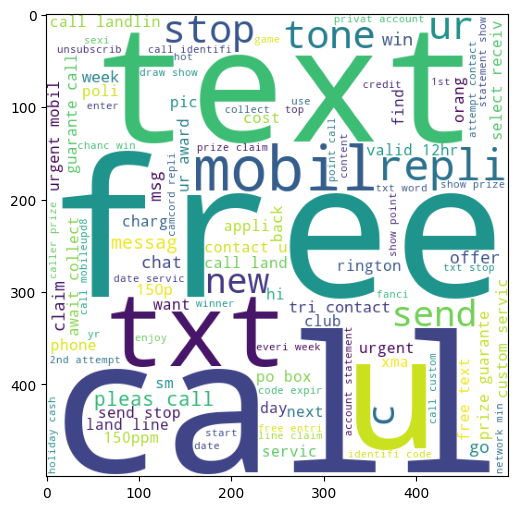

In [95]:
plt.figure(figsize=(12,6))
plt.imshow(spam_wc)

In [96]:
ham_wc = wc.generate(df[df['target'] == 0]['tansformed_text'].str.cat(sep=" "))

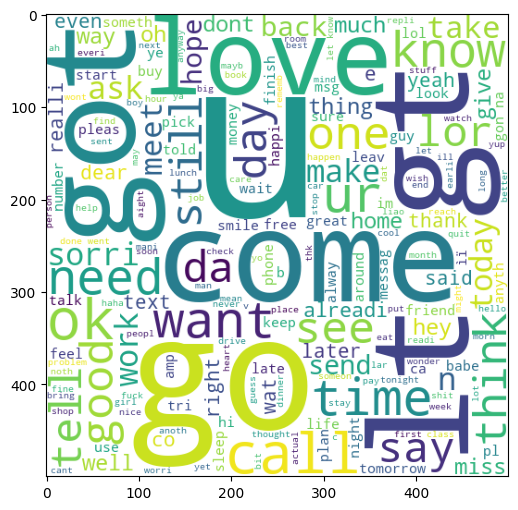

In [97]:
plt.figure(figsize=(12,6))
plt.imshow(ham_wc)

In [98]:
df.head()

,target,text,num_characters,num_words,num_sentences,tansformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [99]:
spam_corpus =[]
for msg in df[df['target'] == 1]['tansformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)


In [100]:
len(spam_corpus)

9939

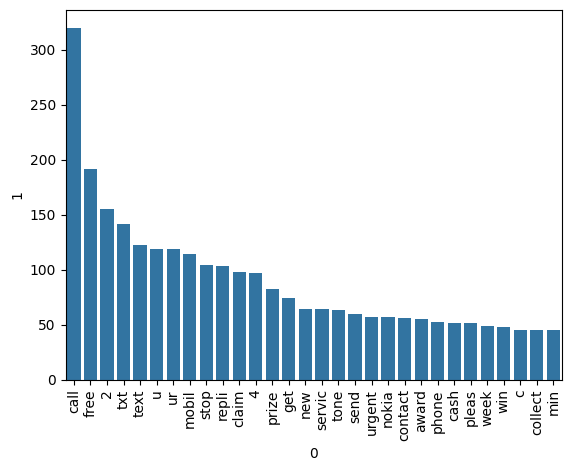

In [101]:
from collections import Counter
df = pd.DataFrame(Counter(spam_corpus).most_common(30))

sns.barplot(x=df[0], y=df[1])

plt.xticks(rotation='vertical')
plt.show()

In [ ]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

KeyError: 'target'